In [1]:
# Step 1 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Step 3 — Check Milestone 2 Clustering folder contents
!ls "/content/drive/MyDrive/StudyTrack_AI_StudentRecommend/Milestone_2_Clustering/"


 clustered_students.csv  'clustering (2).ipynb'   visualizations


In [4]:
# Step 4 — Load the clustered dataset
import pandas as pd
import os

# Update this line with your exact file name
INPUT_CLUSTERED_CSV = "/content/drive/MyDrive/StudyTrack_AI_StudentRecommend/Milestone_2_Clustering/clustered_students.csv"

# Check if file exists
if not os.path.exists(INPUT_CLUSTERED_CSV):
    raise FileNotFoundError(f" File not found: {INPUT_CLUSTERED_CSV}\nPlease verify the filename above.")

# Load dataset
df = pd.read_csv(INPUT_CLUSTERED_CSV)
print("File loaded successfully!")
print("Shape:", df.shape)
df.head()


✅ File loaded successfully!
Shape: (1000, 17)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,cluster
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2,0
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0,2
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3,0
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8,0
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4,1


In [9]:
# Check what columns exist in your dataframe
print("Available columns:\n", df.columns.tolist())

# Show first few rows to see actual column names
df.head()


Available columns:
 ['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score', 'cluster']


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,cluster
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2,0
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0,2
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3,0
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8,0
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4,1


In [10]:
# Rename the existing cluster column to ClusterID
df.rename(columns={'cluster': 'ClusterID'}, inplace=True)

# Verify
print(df.columns.tolist())


['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score', 'ClusterID']


In [11]:
# Generate recommendations based on ClusterID
def generate_recommendation(cluster_id):
    if cluster_id == 0:
        return "High performers – maintain consistent study routine"
    elif cluster_id == 1:
        return "Medium performers – increase study time by 1 hour/day"
    elif cluster_id == 2:
        return "Low performers – focus on basics and seek mentorship"
    else:
        return "General improvement – maintain steady progress"

# Apply the function
df["Recommendation"] = df["ClusterID"].apply(generate_recommendation)

# Show updated dataframe
df.head()


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,ClusterID,Recommendation
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2,0,High performers – maintain consistent study ro...
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0,2,Low performers – focus on basics and seek ment...
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3,0,High performers – maintain consistent study ro...
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8,0,High performers – maintain consistent study ro...
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4,1,Medium performers – increase study time by 1 h...


In [12]:
print(df.columns)


Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score',
       'ClusterID', 'Recommendation'],
      dtype='object')


In [6]:
# Step 6 — Save updated dataset with recommendations
output_path = "/content/drive/MyDrive/StudyTrack_AI_StudentRecommend/Milestone_3_Recommendation/recommended_students.csv"

# Create folder if it doesn't exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

df.to_csv(output_path, index=False)
print("File saved successfully at:", output_path)


✅ File saved successfully at: /content/drive/MyDrive/StudyTrack_AI_StudentRecommend/Milestone_3_Recommendation/recommended_students.csv


/tmp/ipython-input-740460606.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Recommendation", data=df, palette="coolwarm")


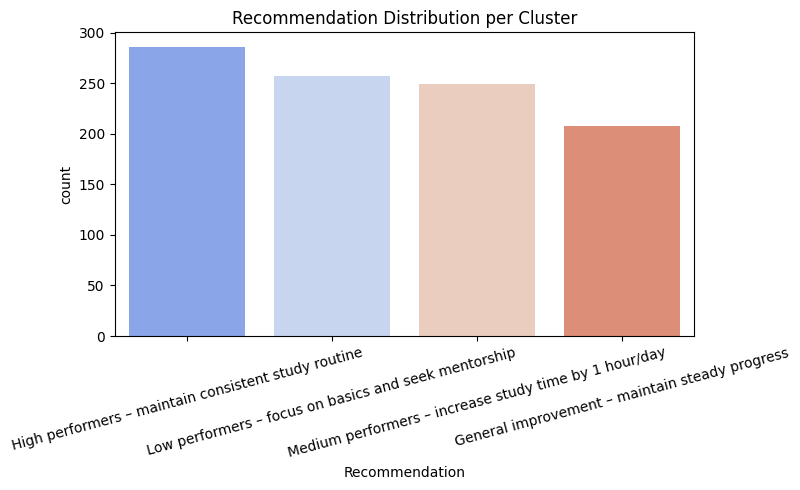

In [13]:
# Step 7 — Visualize recommendation count distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x="Recommendation", data=df, palette="coolwarm")
plt.title("Recommendation Distribution per Cluster")
plt.xticks(rotation=15)
plt.tight_layout()

# Save visualization
os.makedirs("/content/drive/MyDrive/StudyTrack_AI_StudentRecommend/Milestone_3_Recommendation/visualizations", exist_ok=True)
plt.savefig("/content/drive/MyDrive/StudyTrack_AI_StudentRecommend/Milestone_3_Recommendation/visualizations/recommendation_countplot.png")

plt.show()
